
# 不等間隔データのフーリエ級数補間

このノートブックでは、カム角度に対して不等間隔で得られたデータを入力し、
フーリエ級数近似で等間隔データへ補間する。

## 関数の説明

| 関数名 | 役割 | 主な入力 | 主な出力 |
|---|---|---|---|
| `build_design_matrix` | 角度から説明行列 $X$ を作る | `cam_angle_deg`, `order` | `X` |
| `fit_fourier_model` | 最小二乗で係数 $\beta$ を求める | `cam_angle_deg`, `data_value`, `order` | `beta` |
| `predict_fourier` | 任意角度で補間値を計算する | `cam_angle_deg`, `beta`, `order` | `y_hat` |
| `make_equal_grid` | 等間隔サンプリング点を作る | `sampling_step_deg` または `n_samples` | `equal_angle_deg` |
| `interpolate_periodic_fourier` | 全体をまとめて実行する主関数 | `cam_angle_deg`, `data_value`, `order`, サンプリング設定 | 2組の出力 |

## 入力

- `cam_angle_deg` : カム角度
- `data_value` : 観測値
- `order` : フーリエ級数の次数
- `sampling_step_deg` または `n_samples` : 等間隔サンプリングの設定値

## 出力

- `(equal_angle_deg, equal_interp_value)`
- `(input_angle_deg_sorted, input_interp_value_sorted)`

## 依存関係

```text
interpolate_periodic_fourier
├─ fit_fourier_model
│  └─ build_design_matrix
├─ predict_fourier
│  └─ build_design_matrix
└─ make_equal_grid
```

## データの流れ

```text
(cam_angle_deg, data_value)
        │
        ├──> fit_fourier_model ───> beta
        │
        ├──> make_equal_grid ─────> equal_angle_deg
        │                             │
        │                             └──> predict_fourier ───> equal_interp_value
        │
        └────────────────────────────────> predict_fourier ───> input_interp_value_sorted
```

## 必要な Python ライブラリ

| ライブラリ | 用途 |
|---|---|
| `numpy` | 配列計算、三角関数、最小二乗法 |
| `matplotlib` | 確認用の可視化 |

## 使う式

補間式は次である。

$$
\hat{y}(x)
=
a_0
+
\sum_{k=1}^{K}
\left[
a_k \cos\left(\frac{2\pi kx}{360}\right)
+
b_k \sin\left(\frac{2\pi kx}{360}\right)
\right]
$$

行列で書くと、

$$
\boldsymbol{y} \approx X\boldsymbol{\beta}
$$

であり、係数は最小二乗で求める。

$$
\hat{\boldsymbol{\beta}}
=
\arg\min_{\boldsymbol{\beta}}
\left\|
\boldsymbol{y} - X\boldsymbol{\beta}
\right\|^2
$$


In [1]:

import numpy as np
import matplotlib.pyplot as plt


def build_design_matrix(cam_angle_deg, order=3):
    """角度[deg]から説明行列を作る。"""
    cam_angle_deg = np.asarray(cam_angle_deg, dtype=float).reshape(-1)
    theta = 2.0 * np.pi * np.mod(cam_angle_deg, 360.0) / 360.0

    cols = [np.ones_like(theta)]
    for k in range(1, order + 1):
        cols.append(np.cos(k * theta))
        cols.append(np.sin(k * theta))

    return np.column_stack(cols)


def fit_fourier_model(cam_angle_deg, data_value, order=3):
    """最小二乗で係数 beta を求める。"""
    cam_angle_deg = np.asarray(cam_angle_deg, dtype=float).reshape(-1)
    data_value = np.asarray(data_value, dtype=float).reshape(-1)

    if len(cam_angle_deg) != len(data_value):
        raise ValueError("cam_angle_deg と data_value の長さが一致していません。")
    if len(cam_angle_deg) == 0:
        raise ValueError("入力が空です。")

    valid = np.isfinite(cam_angle_deg) & np.isfinite(data_value)
    cam_angle_deg = np.mod(cam_angle_deg[valid], 360.0)
    data_value = data_value[valid]

    if len(cam_angle_deg) == 0:
        raise ValueError("有効なデータがありません。")
    if len(cam_angle_deg) < 2 * order + 1:
        raise ValueError(f"order={order} では少なくとも {2 * order + 1} 点必要です。")

    X = build_design_matrix(cam_angle_deg, order=order)
    beta, *_ = np.linalg.lstsq(X, data_value, rcond=None)
    return beta


def predict_fourier(cam_angle_deg, beta, order=3):
    """指定角度で補間値を計算する。"""
    X = build_design_matrix(cam_angle_deg, order=order)
    return X @ np.asarray(beta, dtype=float).reshape(-1)


def make_equal_grid(sampling_step_deg=None, n_samples=None):
    """等間隔サンプリング点を作る。"""
    if (sampling_step_deg is None) == (n_samples is None):
        raise ValueError("sampling_step_deg と n_samples はどちらか一方だけ指定してください。")

    if sampling_step_deg is not None:
        sampling_step_deg = float(sampling_step_deg)
        if sampling_step_deg <= 0:
            raise ValueError("sampling_step_deg は正の値で指定してください。")
        n = int(np.floor(360.0 / sampling_step_deg))
        return np.arange(n) * sampling_step_deg

    n_samples = int(n_samples)
    if n_samples <= 0:
        raise ValueError("n_samples は 1 以上で指定してください。")
    return np.arange(n_samples) * 360.0 / n_samples


def interpolate_periodic_fourier(
    cam_angle_deg,
    data_value,
    order=3,
    sampling_step_deg=None,
    n_samples=None,
):
    """不等間隔データをフーリエ級数で補間する主関数。"""
    cam_angle_deg = np.asarray(cam_angle_deg, dtype=float).reshape(-1)
    data_value = np.asarray(data_value, dtype=float).reshape(-1)

    beta = fit_fourier_model(cam_angle_deg, data_value, order=order)

    equal_angle_deg = make_equal_grid(
        sampling_step_deg=sampling_step_deg,
        n_samples=n_samples,
    )
    equal_interp_value = predict_fourier(equal_angle_deg, beta, order=order)

    input_angle_deg_sorted = np.mod(cam_angle_deg, 360.0)
    sort_idx = np.argsort(input_angle_deg_sorted)
    input_angle_deg_sorted = input_angle_deg_sorted[sort_idx]
    input_interp_value_sorted = predict_fourier(input_angle_deg_sorted, beta, order=order)

    return (
        (equal_angle_deg, equal_interp_value),
        (input_angle_deg_sorted, input_interp_value_sorted),
    )


## 使用例

ここでは、約300点の不等間隔サンプルデータを作って補間する。

In [2]:

# 約300点の不等間隔サンプルデータを作る
rng = np.random.default_rng(42)

def true_wave(angle_deg):
    theta = 2.0 * np.pi * angle_deg / 360.0
    return (
        0.8
        + 1.4 * np.cos(theta)
        + 0.5 * np.sin(theta)
        + 0.35 * np.cos(2 * theta)
        - 0.2 * np.sin(3 * theta)
    )

n_input = 300
cam_angle_deg = np.sort(rng.uniform(0.0, 360.0, size=n_input))
data_value = true_wave(cam_angle_deg) + rng.normal(0.0, 0.08, size=n_input)

(equal_angle_deg, equal_interp_value), (input_angle_deg_sorted, input_interp_value_sorted) = (
    interpolate_periodic_fourier(
        cam_angle_deg=cam_angle_deg,
        data_value=data_value,
        order=3,
        n_samples=360,
    )
)

print("入力データ点数              :", len(cam_angle_deg))
print("等間隔サンプリング角度 shape:", equal_angle_deg.shape)
print("等間隔補間値 shape          :", equal_interp_value.shape)
print("入力角度 shape              :", input_angle_deg_sorted.shape)
print("入力角度での補間値 shape    :", input_interp_value_sorted.shape)

print("\n先頭10点だけ表示")
for a, y_obs, y_hat in zip(
    np.round(input_angle_deg_sorted[:10], 3),
    np.round(data_value[np.argsort(np.mod(cam_angle_deg, 360.0))][:10], 4),
    np.round(input_interp_value_sorted[:10], 4),
):
    print(f"angle={a:7.3f} deg, observed={y_obs:8.4f}, interp={y_hat:8.4f}")


入力データ点数              : 300
等間隔サンプリング角度 shape: (360,)
等間隔補間値 shape          : (360,)
入力角度 shape              : (300,)
入力角度での補間値 shape    : (300,)

先頭10点だけ表示
angle=  2.650 deg, observed=  2.5191, interp=  2.5333
angle=  5.017 deg, observed=  2.5228, interp=  2.5227
angle=  6.421 deg, observed=  2.5022, interp=  2.5146
angle=  7.613 deg, observed=  2.5262, interp=  2.5067
angle=  7.780 deg, observed=  2.6305, interp=  2.5055
angle=  8.176 deg, observed=  2.3044, interp=  2.5027
angle=  8.209 deg, observed=  2.4905, interp=  2.5024
angle=  8.949 deg, observed=  2.5176, interp=  2.4968
angle= 11.094 deg, observed=  2.5081, interp=  2.4787
angle= 13.469 deg, observed=  2.4306, interp=  2.4558


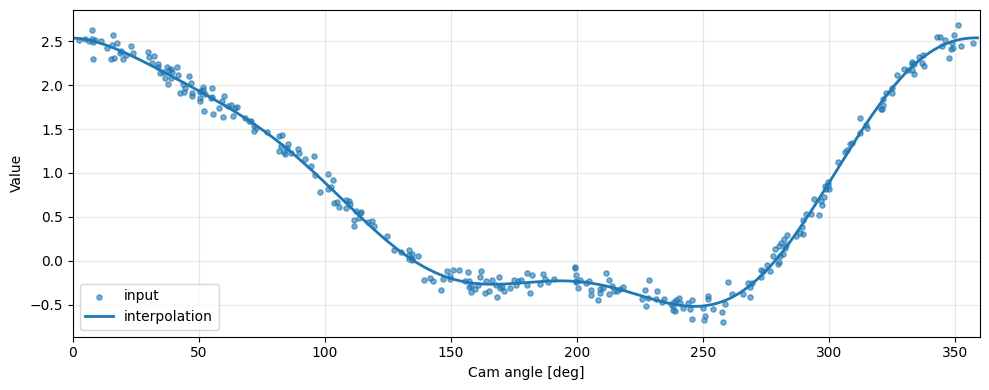

In [3]:

plt.figure(figsize=(10, 4))
plt.scatter(cam_angle_deg, data_value, s=14, alpha=0.6, label="input")
plt.plot(equal_angle_deg, equal_interp_value, linewidth=2, label="interpolation")
plt.xlim(0, 360)
plt.xlabel("Cam angle [deg]")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## 出力の意味

主関数 `interpolate_periodic_fourier(...)` の返り値は次の 2 組である。

```python
(
    (equal_angle_deg, equal_interp_value),
    (input_angle_deg_sorted, input_interp_value_sorted),
)
```

- `equal_angle_deg`  
  等間隔サンプリング角度
- `equal_interp_value`  
  その角度での補間値
- `input_angle_deg_sorted`  
  入力角度を $0 \le x < 360$ で並べ替えたもの
- `input_interp_value_sorted`  
  その入力角度位置での補間値
